# Pipeline de Clustering — Saber Pro
### KMeans · GMM · DBSCAN · HDBSCAN sobre UMAP (CPU)
> **Estrategia en dos fases:**
> - **Fase 1** — búsqueda de hiperparámetros sobre 200k
> - **Fase 2** — modelo final sobre 500k con la mejor configuración

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.colors import TwoSlopeNorm
from scipy.stats import kruskal, chi2_contingency
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (silhouette_score, calinski_harabasz_score,
                              davies_bouldin_score)
from sklearn.cluster import MiniBatchKMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
import hdbscan
import umap.umap_ as umap_cpu
import warnings
warnings.filterwarnings("ignore")

print("✅ Librerías cargadas — modo CPU")


✅ Librerías cargadas — modo CPU


## 2. Carga de datos

In [2]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Proyecto/df_maestra.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed|^Column1')]
print(f"Shape original: {df.shape}")
df.head(3)


Mounted at /content/drive
Shape original: (452020, 83)


,ESTU_TIPODOCUMENTO,ESTU_NACIONALIDAD,ESTU_GENERO,ESTU_FECHANACIMIENTO,ESTU_EXTERIOR,PERIODO,ESTU_CONSECUTIVO,ESTU_ESTUDIANTE,ESTU_PAIS_RESIDE,ESTU_DEPTO_RESIDE,...,MOD_INGLES_PNAL,MOD_INGLES_PNBC,MOD_COMUNI_ESCRITA_PUNT,MOD_COMUNI_ESCRITA_DESEM,MOD_COMUNI_ESCRITA_PNAL,MOD_COMUNI_ESCRITA_PNBC,PUNT_GLOBAL,PERCENTIL_NBC,PERCENTIL_GLOBAL,ESTU_ESTADOINVESTIGACION
0,CC,COLOMBIA,F,14/01/2000,NO,20212,EK202120238705,ESTUDIANTE,COLOMBIA,MAGDALENA,...,97.0,99.0,145,2.0,55,56,193,98.0,97.0,PUBLICAR
1,CC,COLOMBIA,F,09/11/1984,NO,20212,EK202120203222,ESTUDIANTE,COLOMBIA,SANTANDER,...,36.0,49.0,92,1.0,8,10,114,14.0,12.0,PUBLICAR
2,CC,COLOMBIA,F,22/12/1987,NO,20212,EK202120075304,ESTUDIANTE,COLOMBIA,VALLE,...,33.0,30.0,138,2.0,50,51,148,62.0,56.0,PUBLICAR


## 3. Preprocesamiento

In [3]:
def preprocesar_saber_pro(df_raw, sample_n=200_000, random_state=42):
    df_limpio = df_raw.copy()

    # ── Mapeos ordinales — igual que el notebook original ────
    mapa_bano = {
        '1': 1, '2': 2, '3 o 4': 3, '5 o 6': 5, 'MAS DE 6': 6, 'NINGUNA': 0
    }
    mapa_estrato = {
        'Sin estrato': 0, 'Estrato 1': 1, 'Estrato 2': 2,
        'Estrato 3': 3, 'Estrato 4': 4, 'Estrato 5': 5, 'Estrato 6': 6
    }
    mapa_valormatricula = {
        'Sin costo': 0,
        'Menos de 500 mil': 1,
        'Entre 500 mil y menos de 1 millón': 2,
        'Entre 1 millón y menos de 2.5 millones': 3,
        'Entre 2.5 millones y menos de 4 millones': 4,
        'Entre 4 millones y menos de 5.5 millones': 5,
        'Entre 5.5 millones y menos de 7 millones': 6,
        'Más de 7 millones': 7
    }
    mapa_educ = {
        'Ninguno': 0, 'Primaria incompleta': 1, 'Primaria completa': 2,
        'Secundaria (Bachillerato) incompleta': 3,
        'Secundaria (Bachillerato) completa': 4,
        'Técnica o tecnológica incompleta': 5,
        'Técnica o tecnológica completa': 6,
        'Educación profesional incompleta': 7,
        'EDUCACIÓN PROFESIONAL COMPLETA': 8, 'POSTGRADO': 9
    }
    mapeo_horas = {
        '0': 0, 'Menos de 10 horas': 1, 'Entre 11 y 20 horas': 2,
        'Entre 21 y 30 horas': 3, 'Más de 30 horas': 4,
    }
    mapeo_semestre = {str(i).zfill(2): i for i in range(1, 12)}
    mapeo_semestre['12 o más'] = 12

    # Mapear directo sin _upper() — los valores del CSV ya tienen
    # la capitalización correcta para estas columnas
    mapeables = {
        'FAMI_CUANTOSCOMPARTEBAÑO':      mapa_bano,
        'FAMI_ESTRATOVIVIENDA':          mapa_estrato,
        'ESTU_VALORMATRICULAUNIVERSIDAD': mapa_valormatricula,
        'FAMI_EDUCACIONPADRE':           mapa_educ,
        'FAMI_EDUCACIONMADRE':           mapa_educ,
        'ESTU_HORASSEMANATRABAJA':       mapeo_horas,
        'ESTU_SEMESTRECURSA':            mapeo_semestre,
    }
    for col, mapa in mapeables.items():
        if col in df_limpio.columns:
            df_limpio[col] = df_limpio[col].map(mapa)

    # Verificar mapeos
    for col in mapeables:
        if col in df_limpio.columns:
            n_nan = df_limpio[col].isna().sum()
            pct   = n_nan / len(df_limpio) * 100
            status = '✅' if pct < 5 else '⚠️ '
            print(f"  {status} {col}: {n_nan:,} NaN ({pct:.1f}%)")

    # ── Columnas por tipo ─────────────────────────────────────
    columnas_puntaje = [
        'MOD_RAZONA_CUANTITAT_PUNT', 'MOD_LECTURA_CRITICA_PUNT',
        'MOD_COMPETEN_CIUDADA_PUNT', 'MOD_INGLES_PUNT',
        'MOD_COMUNI_ESCRITA_PUNT'
    ]
    columnas_ordinales = [
        'FAMI_ESTRATOVIVIENDA', 'ESTU_VALORMATRICULAUNIVERSIDAD',
        'FAMI_EDUCACIONPADRE', 'FAMI_EDUCACIONMADRE',
        'ESTU_HORASSEMANATRABAJA'
    ]
    columnas_nominales = [
        'ESTU_TITULOOBTENIDOBACHILLER',
        'ESTU_PAGOMATRICULABECA', 'ESTU_PAGOMATRICULACREDITO',
        'ESTU_PAGOMATRICULAPADRES', 'ESTU_PAGOMATRICULAPROPIO',
        'ESTU_COMOCAPACITOEXAMENSB11',
        'FAMI_TIENEINTERNET', 'FAMI_TIENECOMPUTADOR',
        'FAMI_TIENEAUTOMOVIL', 'FAMI_TIENELAVADORA'
    ]
    col_geo = 'ESTU_COD_DEPTO_PRESENTACION'

    # ── Imputación antes de construir df_filtrado ─────────────
    for col in columnas_puntaje:
        if col in df_limpio.columns:
            df_limpio[col] = pd.to_numeric(df_limpio[col], errors='coerce')
            df_limpio[col] = df_limpio[col].fillna(df_limpio[col].mean())
    for col in columnas_ordinales:
        if col in df_limpio.columns:
            df_limpio[col] = df_limpio[col].fillna(df_limpio[col].median())
    for col in columnas_nominales:
        if col in df_limpio.columns:
            df_limpio[col] = df_limpio[col].fillna(
                df_limpio[col].mode(dropna=True)[0])

    cols_usar = columnas_ordinales + columnas_puntaje + columnas_nominales
    cols_df   = cols_usar + ([col_geo] if col_geo in df_limpio.columns else [])
    df_filtrado = df_limpio[[c for c in cols_df if c in df_limpio.columns]].copy()
    df_filtrado = df_filtrado.dropna(subset=columnas_puntaje)
    print(f"\n✅ Filas después de limpieza: {len(df_filtrado):,}")

    # ── Escalado y codificación ───────────────────────────────
    cols_punt = [c for c in columnas_puntaje   if c in df_filtrado.columns]
    cols_ord  = [c for c in columnas_ordinales if c in df_filtrado.columns]
    cols_nom  = [c for c in columnas_nominales if c in df_filtrado.columns]

    scaler  = StandardScaler()
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

    X_punt = scaler.fit_transform(df_filtrado[cols_punt])
    X_ohe  = encoder.fit_transform(df_filtrado[cols_nom])
    X = np.hstack([df_filtrado[cols_ord].values, X_punt, X_ohe])

    feature_names = (cols_ord
                     + list(scaler.get_feature_names_out(cols_punt))
                     + list(encoder.get_feature_names_out(cols_nom)))

    # Seguridad: imputar NaN residuales en X (valores no cubiertos por mapas)
    if np.isnan(X).any():
        from sklearn.impute import SimpleImputer
        X = SimpleImputer(strategy='median').fit_transform(X)
        print("⚠️  NaN residuales imputados con mediana")

    # ── Muestreo ──────────────────────────────────────────────
    if sample_n is not None and sample_n < df_filtrado.shape[0]:
        rng = np.random.default_rng(seed=random_state)
        idx = rng.choice(df_filtrado.shape[0], size=sample_n, replace=False)
        df_filtrado = df_filtrado.iloc[idx].reset_index(drop=True)
        X = X[idx]

    print(f"✅ Preprocesamiento completo — shape X: {X.shape}")
    return df_limpio, df_filtrado, X, feature_names, encoder, scaler


## 4. Funciones auxiliares (UMAP + métricas)

In [4]:
def reducir_umap(X, n_components=2, random_state=42, **kwargs):
    reducer = umap_cpu.UMAP(
        n_components=n_components,
        random_state=random_state,
        n_neighbors=10,
        low_memory=True,
        n_jobs=-1,
        **kwargs
    )
    if X.shape[0] > 100_000:
        rng = np.random.default_rng(42)
        idx_fit = rng.choice(X.shape[0], size=80_000, replace=False)
        reducer.fit(X[idx_fit])
        return reducer.transform(X), reducer
    return reducer.fit_transform(X), reducer


def dunn_index(X_np, labels_np):
    unique = np.unique(labels_np)
    unique = unique[unique != -1]
    if len(unique) < 2:
        return np.nan
    clusters  = [X_np[labels_np == l] for l in unique]
    centroids = [c.mean(axis=0) for c in clusters]
    min_inter = min(
        np.linalg.norm(centroids[i] - centroids[j])
        for i in range(len(centroids))
        for j in range(i + 1, len(centroids))
    )
    max_intra = max(
        (np.linalg.norm(c - c.mean(axis=0), axis=1).max() * 2 if len(c) > 1 else 0)
        for c in clusters
    ) or 1
    return min_inter / max_intra


def calcular_metricas(X_np, labels_np, inertia=None, bic=None):
    mask = labels_np != -1
    X_eval, lbl_eval = X_np[mask], labels_np[mask]
    if len(set(lbl_eval)) < 2:
        return None
    sample = min(10_000, len(lbl_eval))
    sil = silhouette_score(X_eval, lbl_eval, sample_size=sample, random_state=42)
    return {
        'silhouette':     round(sil, 4),
        'calinski':       round(calinski_harabasz_score(X_eval, lbl_eval), 2),
        'davies_bouldin': round(davies_bouldin_score(X_eval, lbl_eval), 4),
        'dunn':           round(dunn_index(X_eval, lbl_eval), 4),
        'inertia':        round(inertia, 2) if inertia is not None else None,
        'bic':            round(bic, 2)     if bic     is not None else None,
        'n_clusters':     int(len(set(lbl_eval))),
        'n_ruido':        int((labels_np == -1).sum()),
    }

print("✅ Funciones auxiliares cargadas.")


✅ Funciones auxiliares cargadas.


---
# 🔍 FASE 1 — Búsqueda de hiperparámetros (200k)
> Encuentra la mejor combinación de algoritmo + K + dimensión UMAP.
> Al terminar, anota los mejores valores para usarlos en Fase 2.

## 5. Preprocesar muestra 200k

In [5]:
df_limpio, df_filtrado_200k, X_200k, feature_names, encoder, scaler = \
    preprocesar_saber_pro(df, sample_n=200_000)
print(f"Shape X_200k: {X_200k.shape}")


  ✅ FAMI_CUANTOSCOMPARTEBAÑO: 5,079 NaN (1.1%)
  ✅ FAMI_ESTRATOVIVIENDA: 6,513 NaN (1.4%)
  ⚠️  ESTU_VALORMATRICULAUNIVERSIDAD: 41,984 NaN (9.3%)
  ⚠️  FAMI_EDUCACIONPADRE: 105,977 NaN (23.4%)
  ⚠️  FAMI_EDUCACIONMADRE: 97,594 NaN (21.6%)
  ✅ ESTU_HORASSEMANATRABAJA: 5,069 NaN (1.1%)
  ✅ ESTU_SEMESTRECURSA: 178 NaN (0.0%)

✅ Filas después de limpieza: 452,020
✅ Preprocesamiento completo — shape X: (200000, 32)
Shape X_200k: (200000, 32)


## 6. Fase 1 — KMeans

In [6]:
def evaluar_kmeans(X, dims=range(2, 6), ks=range(2, 9)):
    resultados = []
    for n_dim in dims:
        print(f"\n--- UMAP {n_dim}D ---")
        X_umap, _ = reducir_umap(X, n_components=n_dim)
        print(f"{'K':>3} | {'Silhouette':>10} | {'CH':>12} | {'Davies-B':>10} | {'Dunn':>8} | {'Inertia':>12}")
        print("-" * 65)
        for k in ks:
            try:
                km      = MiniBatchKMeans(n_clusters=k, random_state=42,
                                          n_init='auto', batch_size=10_000)
                labels  = km.fit_predict(X_umap)
                m = calcular_metricas(X_umap, labels, inertia=km.inertia_)
                if m is None: continue
                print(f"K={k:>2} | {m['silhouette']:>10.4f} | {m['calinski']:>12.2f} | "
                      f"{m['davies_bouldin']:>10.4f} | {m['dunn']:>8.4f} | {m['inertia']:>12.2f}")
                resultados.append({'algoritmo': 'KMeans', 'n_dim': n_dim, 'k': k, **m})
            except Exception as e:
                print(f"K={k:>2} → Error: {e}")
    return pd.DataFrame(resultados)

print("=== Fase 1: KMeans ===")
df_res_km = evaluar_kmeans(X_200k, dims=range(2, 6), ks=range(2, 9))


=== Fase 1: KMeans ===

--- UMAP 2D ---
  K | Silhouette |           CH |   Davies-B |     Dunn |      Inertia
-----------------------------------------------------------------
K= 2 |     0.4200 |    167581.42 |     0.9628 |   0.2676 |   2189754.25
K= 3 |     0.4116 |    196106.78 |     0.8454 |   0.2629 |   1366726.75
K= 4 |     0.3904 |    192857.44 |     0.9520 |   0.1893 |   1035427.88
K= 5 |     0.4025 |    194239.94 |     0.8793 |   0.1801 |    832623.38
K= 6 |     0.4026 |    190305.59 |     0.8273 |   0.1950 |    703492.00
K= 7 |     0.4265 |    199486.55 |     0.7596 |   0.1883 |    576725.19
K= 8 |     0.4460 |    227983.94 |     0.6885 |   0.1872 |    448434.69

--- UMAP 3D ---
  K | Silhouette |           CH |   Davies-B |     Dunn |      Inertia
-----------------------------------------------------------------
K= 2 |     0.3996 |    140951.42 |     1.0801 |   0.2066 |   1654965.12
K= 3 |     0.3776 |    127823.13 |     1.0862 |   0.1928 |   1267566.38
K= 4 |     0.4023 |  

## 7. Fase 1 — GMM

In [7]:
def evaluar_gmm(X, dims=range(2, 6), ks=range(2, 9)):
    resultados = []
    for n_dim in dims:
        print(f"\n--- UMAP {n_dim}D ---")
        X_umap, _ = reducir_umap(X, n_components=n_dim)
        print(f"{'K':>3} | {'Silhouette':>10} | {'CH':>12} | {'Davies-B':>10} | {'Dunn':>8} | {'BIC':>14}")
        print("-" * 70)
        for k in ks:
            try:
                gmm    = GaussianMixture(n_components=k, random_state=42,
                                         covariance_type='full', n_init=1)
                labels = gmm.fit_predict(X_umap)
                bic    = gmm.bic(X_umap)
                m = calcular_metricas(X_umap, labels, bic=bic)
                if m is None: continue
                print(f"K={k:>2} | {m['silhouette']:>10.4f} | {m['calinski']:>12.2f} | "
                      f"{m['davies_bouldin']:>10.4f} | {m['dunn']:>8.4f} | {m['bic']:>14.2f}")
                resultados.append({'algoritmo': 'GMM', 'n_dim': n_dim, 'k': k, **m})
            except Exception as e:
                print(f"K={k:>2} → Error: {e}")
    return pd.DataFrame(resultados)

print("=== Fase 1: GMM ===")
df_res_gmm = evaluar_gmm(X_200k, dims=range(2, 6), ks=range(2, 9))


=== Fase 1: GMM ===

--- UMAP 2D ---
  K | Silhouette |           CH |   Davies-B |     Dunn |            BIC
----------------------------------------------------------------------
K= 2 |     0.4238 |    166062.81 |     0.9493 |   0.2570 |     1972773.41
K= 3 |     0.4571 |    209821.94 |     0.7923 |   0.2642 |     1963727.83
K= 4 |     0.3990 |    193399.88 |     0.9167 |   0.1968 |     1948767.99
K= 5 |     0.3928 |    182324.95 |     0.8259 |   0.1925 |     1929785.83
K= 6 |     0.3904 |    178767.02 |     0.8105 |   0.1931 |     1915039.77
K= 7 |     0.3912 |    171905.92 |     0.8213 |   0.1553 |     1901034.42
K= 8 |     0.4078 |    195065.81 |     0.7569 |   0.1286 |     1842904.05

--- UMAP 3D ---
  K | Silhouette |           CH |   Davies-B |     Dunn |            BIC
----------------------------------------------------------------------
K= 2 |     0.4173 |    127185.20 |     1.0423 |   0.2200 |     2393785.77
K= 3 |     0.3850 |    142320.81 |     1.0224 |   0.1865 |     237

## 8. Fase 1 — DBSCAN

=== Fase 1: DBSCAN ===
eps estimados: [np.float64(0.012), np.float64(0.015), np.float64(0.019)]


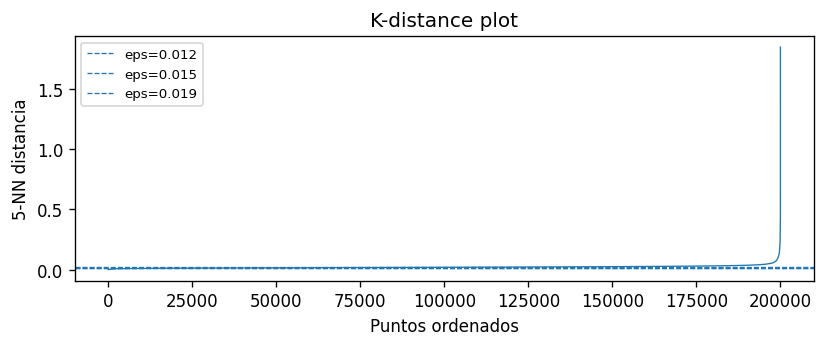


--- DBSCAN sobre UMAP 2D ---
     eps |  min_s |  n_cls |  ruido% | Silhouette |           CH |   Davies-B
------------------------------------------------------------------------
   0.012 |      5 |   5333 |   77.7% |     0.4489 |    413681.56 |     0.4349
   0.012 |     10 |    153 |   98.1% |     0.6044 |   2205220.00 |     0.3320
   0.012 |     20 |     14 |   99.3% |     0.7580 |   9849037.00 |     0.2808
   0.015 |      5 |   8036 |   56.3% |     0.2290 |    108695.93 |     0.5507
   0.015 |     10 |    561 |   94.3% |     0.5846 |    630634.19 |     0.4207
   0.015 |     20 |     19 |   99.1% |     0.8165 |   6957133.50 |     0.2493
   0.019 |      5 |   7191 |   30.6% |     0.0052 |     23443.30 |     0.6859
   0.019 |     10 |   1605 |   81.1% |     0.3914 |    233298.94 |     0.5322
   0.019 |     20 |     49 |   98.2% |     0.7481 |   3388854.75 |     0.3163


In [8]:
def evaluar_dbscan(X, n_dim=2, eps_vals=None, min_samples_vals=None):
    X_umap, _ = reducir_umap(X, n_components=n_dim)
    if eps_vals is None:
        nn = NearestNeighbors(n_neighbors=5, n_jobs=-1)
        nn.fit(X_umap)
        dists, _ = nn.kneighbors(X_umap)
        k_dists  = np.sort(dists[:, -1])
        eps_vals = [round(np.percentile(k_dists, p), 3) for p in [10, 25, 50]]
        print(f"eps estimados: {eps_vals}")
        plt.figure(figsize=(7, 3), dpi=120)
        plt.plot(k_dists, linewidth=0.8)
        for eps in eps_vals:
            plt.axhline(eps, linestyle='--', linewidth=0.8, label=f'eps={eps}')
        plt.xlabel('Puntos ordenados'); plt.ylabel('5-NN distancia')
        plt.title('K-distance plot'); plt.legend(fontsize=8)
        plt.tight_layout(); plt.show()
    if min_samples_vals is None:
        min_samples_vals = [5, 10, 20]
    resultados = []
    print(f"\n--- DBSCAN sobre UMAP {n_dim}D ---")
    print(f"{'eps':>8} | {'min_s':>6} | {'n_cls':>6} | {'ruido%':>7} | {'Silhouette':>10} | {'CH':>12} | {'Davies-B':>10}")
    print("-" * 72)
    for eps in eps_vals:
        for min_s in min_samples_vals:
            try:
                labels    = DBSCAN(eps=eps, min_samples=min_s,
                                   n_jobs=-1).fit_predict(X_umap)
                noise_pct = (labels == -1).mean() * 100
                m = calcular_metricas(X_umap, labels)
                if m is None:
                    print(f"{eps:>8.3f} | {min_s:>6} | {'<2':>6} | {noise_pct:>6.1f}% | —")
                    continue
                print(f"{eps:>8.3f} | {min_s:>6} | {m['n_clusters']:>6} | {noise_pct:>6.1f}% | "
                      f"{m['silhouette']:>10.4f} | {m['calinski']:>12.2f} | {m['davies_bouldin']:>10.4f}")
                resultados.append({'algoritmo': 'DBSCAN', 'n_dim': n_dim,
                                   'eps': eps, 'min_samples': min_s,
                                   'noise_pct': round(noise_pct, 2), **m})
            except Exception as e:
                print(f"{eps:>8.3f} | {min_s:>6} → Error: {e}")
    return pd.DataFrame(resultados), X_umap

print("=== Fase 1: DBSCAN ===")
df_res_db, _ = evaluar_dbscan(X_200k, n_dim=2)


## 9. Fase 1 — HDBSCAN

In [9]:
def evaluar_hdbscan(X, dims=range(2, 6),
                    min_cluster_vals=None, min_samples_vals=None):
    if min_cluster_vals is None: min_cluster_vals = [5, 10, 15]
    if min_samples_vals is None: min_samples_vals = [5, 10]
    resultados = []
    for n_dim in dims:
        print(f"\n--- UMAP {n_dim}D ---")
        X_umap, _ = reducir_umap(X, n_components=n_dim)
        print(f"{'mc':>4} | {'ms':>4} | {'n_cls':>6} | {'ruido%':>7} | "
              f"{'Silhouette':>10} | {'CH':>12} | {'Davies-B':>10}")
        print("-" * 65)
        for mc in min_cluster_vals:
            for ms in min_samples_vals:
                try:
                    labels    = hdbscan.HDBSCAN(
                        min_cluster_size=mc, min_samples=ms
                    ).fit_predict(X_umap)
                    noise_pct = (labels == -1).mean() * 100
                    m = calcular_metricas(X_umap, labels)
                    if m is None:
                        print(f"{mc:>4} | {ms:>4} | {'<2':>6} | {noise_pct:>6.1f}% | —")
                        continue
                    print(f"{mc:>4} | {ms:>4} | {m['n_clusters']:>6} | {noise_pct:>6.1f}% | "
                          f"{m['silhouette']:>10.4f} | {m['calinski']:>12.2f} | {m['davies_bouldin']:>10.4f}")
                    resultados.append({'algoritmo': 'HDBSCAN', 'n_dim': n_dim,
                                       'min_cluster_size': mc, 'min_samples': ms,
                                       'noise_pct': round(noise_pct, 2), **m})
                except Exception as e:
                    print(f"{mc:>4} | {ms:>4} → Error: {e}")
    return pd.DataFrame(resultados)

print("=== Fase 1: HDBSCAN ===")
df_res_hdb = evaluar_hdbscan(X_200k, dims=range(2, 6))


=== Fase 1: HDBSCAN ===

--- UMAP 2D ---
  mc |   ms |  n_cls |  ruido% | Silhouette |           CH |   Davies-B
-----------------------------------------------------------------
   5 |    5 |   6316 |   40.2% |     0.2645 |       728.51 |     0.6025
   5 |   10 |     19 |    0.6% |     0.1107 |      8452.70 |     0.5297
  10 |    5 |     33 |    0.4% |     0.1215 |      7347.81 |     0.4862
  10 |   10 |     15 |    0.4% |     0.2286 |     10964.68 |     0.4931
  15 |    5 |     24 |    0.4% |     0.1127 |     10277.58 |     0.5069
  15 |   10 |     17 |    0.5% |     0.1521 |      9476.34 |     0.4745

--- UMAP 3D ---
  mc |   ms |  n_cls |  ruido% | Silhouette |           CH |   Davies-B
-----------------------------------------------------------------
   5 |    5 |     45 |    1.3% |    -0.0968 |      6284.09 |     0.7098
   5 |   10 |     23 |    1.9% |     0.2042 |     12416.10 |     0.6039
  10 |    5 |     24 |    1.3% |     0.0970 |     12093.99 |     0.6268
  10 |   10 |     

## 10. Resumen Fase 1

In [10]:
df_fase1 = pd.concat([df_res_km, df_res_gmm, df_res_db, df_res_hdb],
                      ignore_index=True)

cols_show = ['algoritmo', 'n_dim', 'n_clusters', 'silhouette',
             'calinski', 'davies_bouldin', 'dunn', 'noise_pct']
cols_show = [c for c in cols_show if c in df_fase1.columns]

print("=== TOP 15 configuraciones por Silhouette ===")
print(df_fase1.sort_values('silhouette', ascending=False)[cols_show]
              .head(15).to_string(index=False))

df_fase1.to_csv('/content/drive/MyDrive/Proyecto/resultados_fase1.csv', index=False)
print("\n✅ Guardado: resultados_fase1.csv")


=== TOP 15 configuraciones por Silhouette ===
algoritmo  n_dim  n_clusters  silhouette     calinski  davies_bouldin   dunn  noise_pct
   DBSCAN      2          19      0.8165 6.957134e+06          0.2493 0.1899      99.06
   DBSCAN      2          14      0.7580 9.849037e+06          0.2808 0.0956      99.32
   DBSCAN      2          49      0.7481 3.388855e+06          0.3163 0.1298      98.21
   DBSCAN      2         153      0.6044 2.205220e+06          0.3320 0.0970      98.08
   DBSCAN      2         561      0.5846 6.306342e+05          0.4207 0.0380      94.28
      GMM      2           3      0.4571 2.098219e+05          0.7923 0.2642        NaN
   DBSCAN      2        5333      0.4489 4.136816e+05          0.4349 0.0292      77.65
   KMeans      2           8      0.4460 2.279839e+05          0.6885 0.1872        NaN
   KMeans      2           7      0.4265 1.994865e+05          0.7596 0.1883        NaN
      GMM      2           2      0.4238 1.660628e+05          0.9493 0.25

---
# 🚀 FASE 2 — Modelo final sobre 500k
> Ajusta `BEST_*` según el TOP de Fase 1 antes de ejecutar.

## 11. Preprocesar 500k completos

In [11]:
df_limpio_full, df_filtrado_full, X_full, _, _, _ = \
    preprocesar_saber_pro(df, sample_n=None)
print(f"Shape X_full: {X_full.shape}")


  ✅ FAMI_CUANTOSCOMPARTEBAÑO: 5,079 NaN (1.1%)
  ✅ FAMI_ESTRATOVIVIENDA: 6,513 NaN (1.4%)
  ⚠️  ESTU_VALORMATRICULAUNIVERSIDAD: 41,984 NaN (9.3%)
  ⚠️  FAMI_EDUCACIONPADRE: 105,977 NaN (23.4%)
  ⚠️  FAMI_EDUCACIONMADRE: 97,594 NaN (21.6%)
  ✅ ESTU_HORASSEMANATRABAJA: 5,069 NaN (1.1%)
  ✅ ESTU_SEMESTRECURSA: 178 NaN (0.0%)

✅ Filas después de limpieza: 452,020
✅ Preprocesamiento completo — shape X: (452020, 32)
Shape X_full: (452020, 32)


## 12. Entrenar modelo final

In [12]:
# ── Configuración final — basada en Fase 1 ───────────────────
# KMeans K=6 UMAP 2D: mejor balance métricas + interpretabilidad
BEST_ALGO  = 'KMeans'
BEST_K     = 8
BEST_NDIM  = 2

# Parámetros alternativos (solo si cambias BEST_ALGO)
DBSCAN_EPS         = 0.5
DBSCAN_MINSAMPLES  = 10
HDBSCAN_MC         = 10
HDBSCAN_MS         = 5

print(f"Config: {BEST_ALGO} | K={BEST_K} | UMAP {BEST_NDIM}D | n={X_full.shape[0]:,}")

# UMAP en dimensión óptima para clustering
print(f"\n⏳ Calculando UMAP {BEST_NDIM}D sobre {X_full.shape[0]:,} datos...")
X_umap_full, reducer = reducir_umap(X_full, n_components=BEST_NDIM) # Changed this line to store reducer
print(f"✅ UMAP listo — shape: {X_umap_full.shape}")

# UMAP 2D separado solo para visualización (si BEST_NDIM != 2)
if BEST_NDIM == 2:
    X_umap_viz = X_umap_full
else:
    print("⏳ Calculando UMAP 2D para visualización...")
    X_umap_viz, _ = reducir_umap(X_full, n_components=2, min_dist=0.3)
    print("✅ UMAP 2D listo")

# Entrenar modelo
print(f"\n⏳ Entrenando {BEST_ALGO}...")
if BEST_ALGO == 'KMeans':
    km = MiniBatchKMeans(n_clusters=BEST_K, random_state=42,
                          n_init='auto', batch_size=10_000)
    labels_final = km.fit_predict(X_umap_full)

elif BEST_ALGO == 'GMM':
    gmm = GaussianMixture(n_components=BEST_K, random_state=42,
                           covariance_type='full', n_init=1)
    labels_final = gmm.fit_predict(X_umap_full)

elif BEST_ALGO == 'DBSCAN':
    labels_final = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MINSAMPLES,
                           n_jobs=-1).fit_predict(X_umap_full)

elif BEST_ALGO == 'HDBSCAN':
    labels_final = hdbscan.HDBSCAN(
        min_cluster_size=HDBSCAN_MC, min_samples=HDBSCAN_MS
    ).fit_predict(X_umap_full)

# Métricas en espacio UMAP
m_final = calcular_metricas(X_umap_full, labels_final)
print(f"\n📊 Métricas en espacio UMAP {BEST_NDIM}D:")
for key, val in m_final.items():
    if val is not None:
        print(f"   {key}: {val}")

df_filtrado_full['_cluster'] = labels_final
NOMBRES_CLUSTERS = {i: f'Cluster {i}' for i in range(BEST_K)}


Config: KMeans | K=8 | UMAP 2D | n=452,020

⏳ Calculando UMAP 2D sobre 452,020 datos...
✅ UMAP listo — shape: (452020, 2)

⏳ Entrenando KMeans...

📊 Métricas en espacio UMAP 2D:
   silhouette: 0.42809998989105225
   calinski: 532938.25
   davies_bouldin: 0.7438
   dunn: 0.17409999668598175
   n_clusters: 8
   n_ruido: 0


Guardar modelo

In [13]:
import joblib
import os

SAVE_PATH = '/content/drive/MyDrive/Proyecto/modelos/'
os.makedirs(SAVE_PATH, exist_ok=True)

# ── Guardar modelo KMeans ─────────────────────────────────────
joblib.dump(km, f'{SAVE_PATH}kmeans_k{BEST_K}.pkl')
print(f"✅ KMeans guardado")

# ── Guardar proyección UMAP ───────────────────────────────────
# Guardar el reducer y la proyección completa
joblib.dump(reducer, f'{SAVE_PATH}umap_reducer_2d.pkl')  # el objeto reducer
np.save(f'{SAVE_PATH}X_umap_full.npy', X_umap_full)      # la matriz ya reducida
np.save(f'{SAVE_PATH}labels_final.npy', labels_final)     # los labels
print(f"✅ UMAP reducer y proyección guardados")

# ── Guardar preprocesadores ───────────────────────────────────
joblib.dump(scaler,  f'{SAVE_PATH}scaler.pkl')
joblib.dump(encoder, f'{SAVE_PATH}encoder.pkl')
print(f"✅ Scaler y encoder guardados")

# ── Guardar df_filtrado_full con clusters ─────────────────────
df_filtrado_full.to_parquet(f'{SAVE_PATH}df_clustered.parquet', index=False)
print(f"✅ DataFrame con clusters guardado (.parquet)")

print(f"\n📁 Archivos en {SAVE_PATH}:")
for f in os.listdir(SAVE_PATH):
    size = os.path.getsize(f'{SAVE_PATH}{f}') / 1e6
    print(f"   {f:<40} {size:.1f} MB")

✅ KMeans guardado
✅ UMAP reducer y proyección guardados
✅ Scaler y encoder guardados
✅ DataFrame con clusters guardado (.parquet)

📁 Archivos en /content/drive/MyDrive/Proyecto/modelos/:
   umap_reducer_2d.pkl                      63.5 MB
   X_umap_full.npy                          3.6 MB
   labels_final.npy                         1.8 MB
   scaler.pkl                               0.0 MB
   encoder.pkl                              0.0 MB
   df_clustered.parquet                     4.1 MB
   kmeans_k8.pkl                            1.8 MB


In [28]:
# Puntajes promedio por cluster K=8
cols_punt = ['MOD_RAZONA_CUANTITAT_PUNT', 'MOD_LECTURA_CRITICA_PUNT',
             'MOD_COMPETEN_CIUDADA_PUNT', 'MOD_INGLES_PUNT', 'MOD_COMUNI_ESCRITA_PUNT']

resumen = (df_filtrado_full.groupby('_cluster')[cols_punt]
                           .mean().round(2)
                           .rename(index=NOMBRES_CLUSTERS))
print(resumen.to_string())

# Tamaños
print("\n=== Tamaños ===")
for c in sorted(set(labels_final)):
    n = (labels_final == c).sum()
    pct = n / len(labels_final) * 100
    print(f"Cluster {c}: n={n:,} ({pct:.1f}%)")

# Top 3 departamentos por cluster
print("\n=== Top 3 deptos por cluster ===")
for c in [f'Cluster {i}' for i in range(8)]:
    if c in tabla.columns:
        top3 = tabla[c].sort_values(ascending=False).head(3)
        print(f"\n{c}:")
        for dep, pct in top3.items():
            print(f"  {dep}: {pct:.0f}%")

           MOD_RAZONA_CUANTITAT_PUNT  MOD_LECTURA_CRITICA_PUNT  MOD_COMPETEN_CIUDADA_PUNT  MOD_INGLES_PUNT  MOD_COMUNI_ESCRITA_PUNT
_cluster                                                                                                                           
Cluster 0                     135.81                    137.22                     133.01           137.27                   136.29
Cluster 1                     148.77                    152.25                     147.08           161.47                   141.48
Cluster 2                     146.15                    149.63                     143.25           155.19                   134.24
Cluster 3                     140.81                    141.47                     137.13           147.36                   137.84
Cluster 4                     160.80                    163.35                     159.05           179.12                   147.56
Cluster 5                     146.80                    150.61              

Si necesito volver a correr el modelo esta cargado

In [ ]:
'''import joblib, numpy as np, pandas as pd

SAVE_PATH = '/content/drive/MyDrive/Proyecto/modelos/'

# Cargar todo
km            = joblib.load(f'{SAVE_PATH}kmeans_k8.pkl')
reducer       = joblib.load(f'{SAVE_PATH}umap_reducer_2d.pkl')
scaler        = joblib.load(f'{SAVE_PATH}scaler.pkl')
encoder       = joblib.load(f'{SAVE_PATH}encoder.pkl')
X_umap_full   = np.load(f'{SAVE_PATH}X_umap_full.npy')
labels_final  = np.load(f'{SAVE_PATH}labels_final.npy')
df_filtrado_full = pd.read_parquet(f'{SAVE_PATH}df_clustered.parquet')

BEST_K    = 8
BEST_NDIM = 2
NOMBRES_CLUSTERS = {i: f'Cluster {i}' for i in range(BEST_K)}

print(f"✅ Todo cargado — {len(df_filtrado_full):,} estudiantes, {BEST_K} clusters")
print(f"   Labels únicos: {sorted(set(labels_final))}")'''

## 12b. Ablation study — validación metodológica
> Compara clustering sin reducción, con PCA y con UMAP.
> Necesario para justificar el uso de UMAP en el artículo.

In [15]:
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

print("=" * 65)
print("ABLATION STUDY — Justificación de UMAP")
print("=" * 65)

# ── 1. Sin reducción dimensional ─────────────────────────────
print("\n⏳ KMeans directo sobre X (sin reducción)...")
km_raw     = MiniBatchKMeans(n_clusters=BEST_K, random_state=42,
                              n_init='auto', batch_size=10_000)
labels_raw = km_raw.fit_predict(X_full)
m_raw      = calcular_metricas(X_full, labels_raw)

# ── 2. Con PCA ────────────────────────────────────────────────
print("⏳ PCA + KMeans...")
pca   = PCA(n_components=0.80, random_state=42)
X_pca = pca.fit_transform(X_full)
n_pca = X_pca.shape[1]
print(f"   PCA → {n_pca} componentes ({pca.explained_variance_ratio_.sum()*100:.1f}% varianza)")
km_pca     = MiniBatchKMeans(n_clusters=BEST_K, random_state=42,
                              n_init='auto', batch_size=10_000)
labels_pca = km_pca.fit_predict(X_pca)
m_pca      = calcular_metricas(X_pca, labels_pca)

# ── 3. Con UMAP (ya calculado) ────────────────────────────────
# m_final ya está calculado en celda anterior

# ── 4. Validación en espacio original ────────────────────────
print("⏳ Validando clusters UMAP en espacio original...")
m_orig = calcular_metricas(X_full, labels_final)

# ── Tabla comparativa ─────────────────────────────────────────
print("\n" + "=" * 65)
print(f"{'Método':<25} | {'Dims':>5} | {'Silhouette':>10} | {'CH':>12} | {'DB':>8}")
print("-" * 65)
print(f"{'Sin reducción':<25} | {X_full.shape[1]:>5} | {m_raw['silhouette']:>10.4f} | {m_raw['calinski']:>12.2f} | {m_raw['davies_bouldin']:>8.4f}")
print(f"{'PCA (80% varianza)':<25} | {n_pca:>5} | {m_pca['silhouette']:>10.4f} | {m_pca['calinski']:>12.2f} | {m_pca['davies_bouldin']:>8.4f}")
print(f"{'UMAP {BEST_NDIM}D (clustering)':<25} | {BEST_NDIM:>5} | {m_final['silhouette']:>10.4f} | {m_final['calinski']:>12.2f} | {m_final['davies_bouldin']:>8.4f}")
print(f"{'UMAP (en espacio orig.)':<25} | {X_full.shape[1]:>5} | {m_orig['silhouette']:>10.4f} | {m_orig['calinski']:>12.2f} | {m_orig['davies_bouldin']:>8.4f}")
print("=" * 65)

# ── Guardar ablation ──────────────────────────────────────────
df_ablation = pd.DataFrame([
    {'metodo': 'Sin reducción',        'dims': X_full.shape[1], **m_raw},
    {'metodo': f'PCA {n_pca} comps',   'dims': n_pca,           **m_pca},
    {'metodo': f'UMAP {BEST_NDIM}D',   'dims': BEST_NDIM,       **m_final},
    {'metodo': 'UMAP (valid. orig)',   'dims': X_full.shape[1], **m_orig},
])
df_ablation.to_csv('/content/drive/MyDrive/Proyecto/ablation_study.csv', index=False)
print("\n✅ Guardado: ablation_study.csv")


ABLATION STUDY — Justificación de UMAP

⏳ KMeans directo sobre X (sin reducción)...
⏳ PCA + KMeans...
   PCA → 8 componentes (80.8% varianza)
⏳ Validando clusters UMAP en espacio original...

Método                    |  Dims | Silhouette |           CH |       DB
-----------------------------------------------------------------
Sin reducción             |    32 |     0.0949 |     42982.58 |   2.2417
PCA (80% varianza)        |     8 |     0.1051 |     57296.92 |   2.1731
UMAP {BEST_NDIM}D (clustering) |     2 |     0.4281 |    532938.25 |   0.7438
UMAP (en espacio orig.)   |    32 |     0.0534 |     31311.70 |   2.8546

✅ Guardado: ablation_study.csv


## 13. Visualización — UMAP 2D

✅ Guardado: figura_kmeans_k8_500k.png


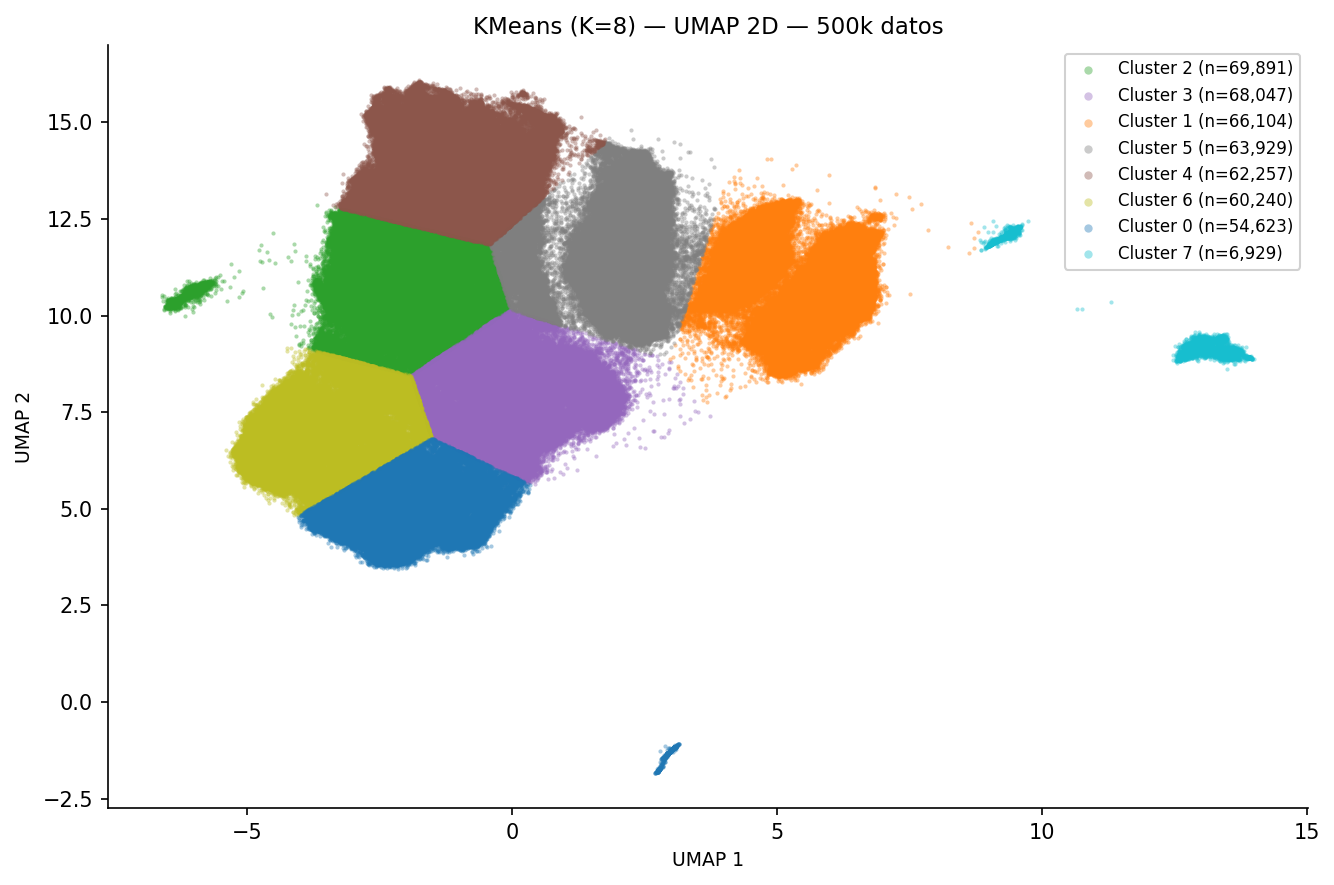

In [16]:
def plot_clusters_2d(X_umap_2d, labels, titulo="Clustering sobre UMAP 2D",
                     nombres=None, colores=None, guardar=None):
    unique_ids = sorted(set(labels))
    if nombres is None:
        nombres = {c: ('Ruido' if c == -1 else f'Cluster {c}') for c in unique_ids}
    if colores is None:
        cmap = plt.cm.tab10(np.linspace(0, 1, max(len(unique_ids), 1)))
        colores = {c: ('gray' if c == -1 else cmap[i]) for i, c in enumerate(unique_ids)}
    fig, ax = plt.subplots(figsize=(9, 6), dpi=150)
    for cid in sorted(unique_ids, key=lambda c: -(labels == c).sum()):
        idx = labels == cid
        ax.scatter(X_umap_2d[idx, 0], X_umap_2d[idx, 1],
                   c=[colores[cid]], s=4, alpha=0.4, linewidths=0,
                   rasterized=True, label=f"{nombres[cid]} (n={idx.sum():,})")
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel("UMAP 1", fontsize=9)
    ax.set_ylabel("UMAP 2", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(markerscale=2, fontsize=8, framealpha=0.9)
    plt.tight_layout()
    if guardar:
        plt.savefig(guardar, dpi=200, bbox_inches='tight', facecolor='white')
        print(f"✅ Guardado: {guardar}")
    plt.show()

plot_clusters_2d(
    X_umap_viz, labels_final,
    titulo=f"{BEST_ALGO} (K={BEST_K}) — UMAP {BEST_NDIM}D — 500k datos",
    nombres=NOMBRES_CLUSTERS,
    guardar=f"figura_{BEST_ALGO.lower()}_k{BEST_K}_500k.png"
)


In [17]:
# Verificar cómo están codificadas las variables binarias
vars_bin = ['FAMI_TIENEINTERNET', 'FAMI_TIENECOMPUTADOR',
            'ESTU_PAGOMATRICULABECA', 'ESTU_PAGOMATRICULACREDITO']

for col in vars_bin:
    if col in df_filtrado_full.columns:
        print(f"\n{col}:")
        print(df_filtrado_full[col].value_counts().head(5))


FAMI_TIENEINTERNET:
FAMI_TIENEINTERNET
Si    408364
No     43656
Name: count, dtype: int64

FAMI_TIENECOMPUTADOR:
FAMI_TIENECOMPUTADOR
Si    406568
No     45452
Name: count, dtype: int64

ESTU_PAGOMATRICULABECA:
ESTU_PAGOMATRICULABECA
No    328741
Si    123279
Name: count, dtype: int64

ESTU_PAGOMATRICULACREDITO:
ESTU_PAGOMATRICULACREDITO
No    320097
Si    131923
Name: count, dtype: int64


In [18]:
# Diagnóstico del chi-cuadrado
col = 'FAMI_TIENEINTERNET'
serie = df_filtrado_full[col].astype(str).str.strip().str.lower().map({'si': 1, 'no': 0})

print("Valores después del map:")
print(serie.value_counts(dropna=False))

print(f"\nNaN después del map: {serie.isna().sum()}")

df_filtrado_full['_tmpbin'] = serie
tabla = pd.crosstab(df_filtrado_full['_cluster'], df_filtrado_full['_tmpbin'])
print("\nTabla de contingencia:")
print(tabla)

from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(tabla)
print(f"\nchi2={chi2:.2f}, p={p:.6f}, -log10(p)={-np.log10(p):.2f}")

Valores después del map:
FAMI_TIENEINTERNET
1    408364
0     43656
Name: count, dtype: int64

NaN después del map: 0

Tabla de contingencia:
_tmpbin       0      1
_cluster              
0          6401  48222
1          4169  61935
2          7649  62242
3          5576  62471
4          1260  60997
5          5222  58707
6         13112  47128
7           267   6662

chi2=16127.01, p=0.000000, -log10(p)=inf


In [27]:
# ❌ Esto falla si los valores son 'SI'/'NO' en mayúsculas
serie = df_work[col].astype(str).str.strip().str.lower().map({'si': 1, 'no': 0})

In [26]:
# ✅ Normaliza a minúsculas antes de mapear
serie = (df_work[col].astype(str)
                     .str.strip()
                     .str.lower()
                     .replace({'s': 1, 'n': 0,   # si acaso son 'S'/'N'
                                'si': 1, 'no': 0,
                                'yes': 1, 'no': 0,
                                '1': 1, '0': 0})
                     .apply(lambda x: x if x in [0, 1] else np.nan))

## 14. Heatmap de caracterización por cluster

=== p-log values ===
           etiqueta  plog
Razonamiento Cuant. 300.0
    Lectura Crítica 300.0
   Comp. Ciudadanas 300.0
             Inglés 300.0
       Com. Escrita 300.0
            Estrato 300.0
    Valor Matrícula 300.0
        Educ. Padre 300.0
        Educ. Madre 300.0
 Horas trabajo/sem. 300.0
               Beca 300.0
            Crédito 300.0
        Paga padres 300.0
        Paga propio 300.0
           Internet 300.0
         Computador 300.0
          Automóvil 300.0
           Lavadora 300.0
✅ Guardado: figura_heatmap_clusters.png


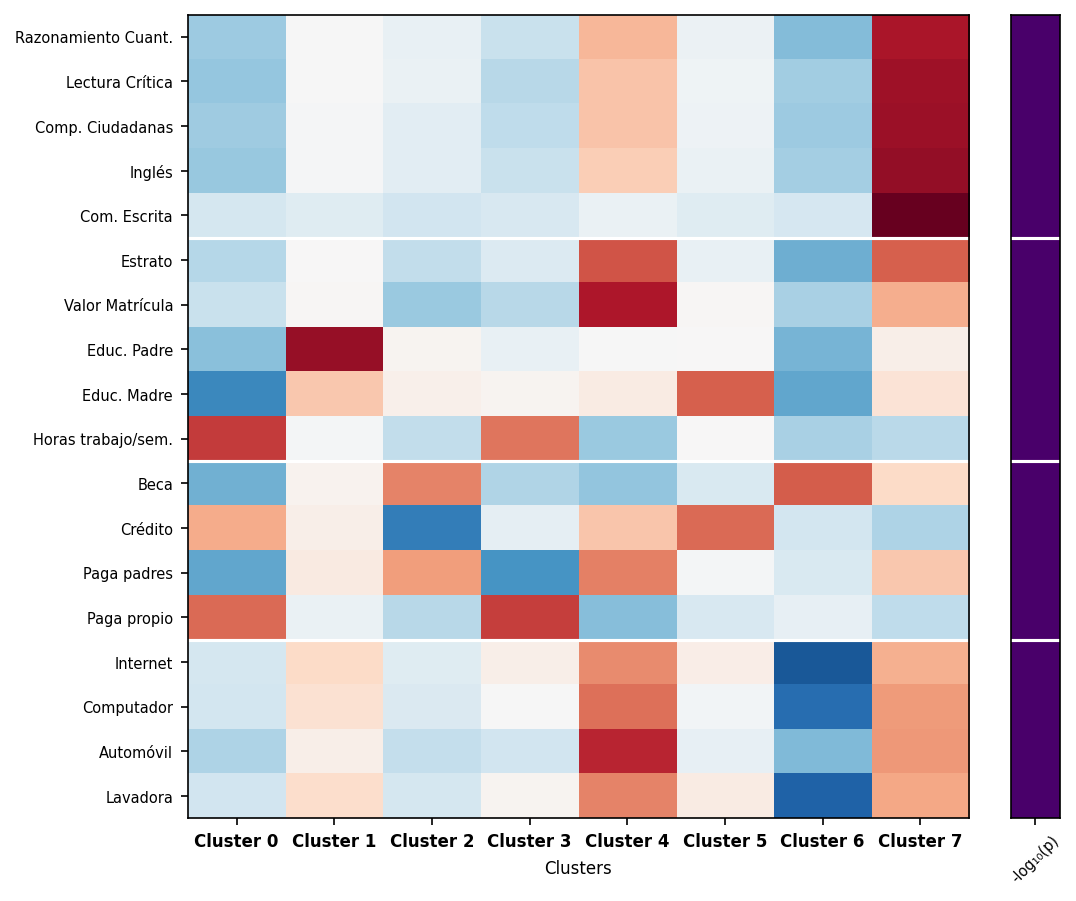

In [20]:
# ── Heatmap de caracterización por cluster ────────────────────
from scipy.stats import kruskal, chi2_contingency
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import numpy as np

GRUPOS_HEATMAP = [
    ("Puntajes académicos", [
        'MOD_RAZONA_CUANTITAT_PUNT', 'MOD_LECTURA_CRITICA_PUNT',
        'MOD_COMPETEN_CIUDADA_PUNT', 'MOD_INGLES_PUNT', 'MOD_COMUNI_ESCRITA_PUNT'
    ], 'quant'),
    ("Perfil socioeconómico", [
        'FAMI_ESTRATOVIVIENDA', 'ESTU_VALORMATRICULAUNIVERSIDAD',
        'FAMI_EDUCACIONPADRE', 'FAMI_EDUCACIONMADRE', 'ESTU_HORASSEMANATRABAJA'
    ], 'quant'),
    ("Financiación matrícula", [
        'ESTU_PAGOMATRICULABECA', 'ESTU_PAGOMATRICULACREDITO',
        'ESTU_PAGOMATRICULAPADRES', 'ESTU_PAGOMATRICULAPROPIO'
    ], 'bin'),
    ("Recursos del hogar", [
        'FAMI_TIENEINTERNET', 'FAMI_TIENECOMPUTADOR',
        'FAMI_TIENEAUTOMOVIL', 'FAMI_TIENELAVADORA'
    ], 'bin'),
]

ETIQUETAS = {
    "MOD_RAZONA_CUANTITAT_PUNT":      "Razonamiento Cuant.",
    "MOD_LECTURA_CRITICA_PUNT":       "Lectura Crítica",
    "MOD_COMPETEN_CIUDADA_PUNT":      "Comp. Ciudadanas",
    "MOD_INGLES_PUNT":                "Inglés",
    "MOD_COMUNI_ESCRITA_PUNT":        "Com. Escrita",
    "FAMI_ESTRATOVIVIENDA":           "Estrato",
    "FAMI_EDUCACIONPADRE":            "Educ. Padre",
    "FAMI_EDUCACIONMADRE":            "Educ. Madre",
    "ESTU_VALORMATRICULAUNIVERSIDAD": "Valor Matrícula",
    "ESTU_HORASSEMANATRABAJA":        "Horas trabajo/sem.",
    "ESTU_PAGOMATRICULABECA":         "Beca",
    "ESTU_PAGOMATRICULACREDITO":      "Crédito",
    "ESTU_PAGOMATRICULAPADRES":       "Paga padres",
    "ESTU_PAGOMATRICULAPROPIO":       "Paga propio",
    "FAMI_TIENEINTERNET":             "Internet",
    "FAMI_TIENECOMPUTADOR":           "Computador",
    "FAMI_TIENEAUTOMOVIL":            "Automóvil",
    "FAMI_TIENELAVADORA":             "Lavadora",
}

# ── 1. Calcular z-scores y p-valores ─────────────────────────
df_work      = df_filtrado_full.copy()
clusters_ids = sorted(c for c in df_work['_cluster'].unique() if c != -1)

rows = []
for grupo, cols, tipo in GRUPOS_HEATMAP:
    for col in cols:
        if col not in df_work.columns:
            continue
        label = ETIQUETAS.get(col, col)

        if tipo == 'quant':
            serie = pd.to_numeric(df_work[col], errors='coerce')
            gvals = [serie[df_work['_cluster'] == c].dropna().values
                     for c in clusters_ids]
            try:
                _, p = kruskal(*gvals)
            except:
                p = np.nan
            medias = np.array([v.mean() if len(v) > 0 else np.nan
                               for v in gvals])

        else:  # binaria
            serie = (df_work[col].astype(str)
                                  .str.strip()
                                  .str.lower()
                                  .map({'si': 1, 'no': 0,
                                        's':  1, 'n':  0,
                                        '1':  1, '0':  0,
                                        'yes': 1}))
            tabla = pd.crosstab(df_work['_cluster'], serie)
            if tabla.shape[1] < 2:
                p = np.nan
            else:
                try:
                    _, p, _, _ = chi2_contingency(tabla)
                except:
                    p = np.nan
            gvals = [serie[df_work['_cluster'] == c].dropna().values
                     for c in clusters_ids]
            medias = np.array([v.mean() if len(v) > 0 else np.nan
                               for v in gvals])

        gm, gs = np.nanmean(medias), np.nanstd(medias)
        zs     = (medias - gm) / gs if gs > 0 else medias * 0

        # ── p-valor → -log10(p) con manejo de p=0.0 exacto ──
        if p is None or np.isnan(p):
            plog = 0.0
        elif p == 0.0:
            # p tan pequeño que Python lo trunca a 0
            # con n=452k casi todas las diferencias son altamente significativas
            plog = 300.0
        else:
            plog = float(-np.log10(p))

        rows.append((grupo, label, col, tipo, *zs, plog))

col_names = (['grupo', 'etiqueta', 'col', 'tipo']
             + [f'z_{c}' for c in clusters_ids] + ['plog'])
df_heat = pd.DataFrame(rows, columns=col_names)

print("=== p-log values ===")
print(df_heat[['etiqueta', 'plog']].to_string(index=False))

# ── 2. Plot ───────────────────────────────────────────────────
n_rows = len(df_heat)
n_cls  = len(clusters_ids)

fig, (ax_h, ax_p) = plt.subplots(
    1, 2,
    figsize=(7.5, n_rows * 0.32 + 1.2),
    dpi=150,
    gridspec_kw={"width_ratios": [n_cls, 0.5], "wspace": 0.1}
)

z_mat = df_heat[[f'z_{c}' for c in clusters_ids]].values.astype(float)
p_mat = df_heat[['plog']].values.astype(float)
vmax  = max(np.nanmax(np.abs(z_mat)), 1.0)
norm  = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

ax_h.imshow(z_mat, aspect='auto', cmap='RdBu_r', norm=norm,
            interpolation='nearest')
ax_p.imshow(p_mat, aspect='auto', cmap='RdPu',
            vmin=0, vmax=max(float(p_mat.max()), 2.0),
            interpolation='nearest')

ax_h.set_yticks(range(n_rows))
ax_h.set_yticklabels(df_heat['etiqueta'], fontsize=7)
ax_h.set_xticks(range(n_cls))
ax_h.set_xticklabels(
    [NOMBRES_CLUSTERS.get(c, f'C{c}') for c in clusters_ids],
    fontsize=8, fontweight='bold'
)
ax_h.set_xlabel("Clusters", fontsize=8)
ax_p.set_xticks([0])
ax_p.set_xticklabels(['-log₁₀(p)'], fontsize=7, rotation=45)
ax_p.set_yticks([])

# Líneas separadoras blancas entre grupos
grupo_sizes = [sum(1 for c in cols if c in df_work.columns)
               for _, cols, _ in GRUPOS_HEATMAP]
acum = 0
for gs in grupo_sizes[:-1]:
    acum += gs
    ax_h.axhline(acum - 0.5, color='white', linewidth=1.5)
    ax_p.axhline(acum - 0.5, color='white', linewidth=1.5)

plt.tight_layout()
plt.savefig('figura_heatmap_clusters.png', dpi=200,
            bbox_inches='tight', facecolor='white')
print("✅ Guardado: figura_heatmap_clusters.png")
plt.show()

In [21]:
print("=== Verificación p_mat ===")
print(f"Shape p_mat: {p_mat.shape}")
print(f"Valores p_mat: {p_mat.flatten()}")
print(f"Max p_mat: {p_mat.max()}")
print(f"Hay valores > 0: {(p_mat > 0).any()}")


=== Verificación p_mat ===
Shape p_mat: (18, 1)
Valores p_mat: [300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.
 300. 300. 300. 300.]
Max p_mat: 300.0
Hay valores > 0: True


## 15. Diagnóstico — puntajes promedio por cluster

In [22]:
cols_punt = ['MOD_RAZONA_CUANTITAT_PUNT', 'MOD_LECTURA_CRITICA_PUNT',
             'MOD_COMPETEN_CIUDADA_PUNT', 'MOD_INGLES_PUNT', 'MOD_COMUNI_ESCRITA_PUNT']

print("=== Tamaño de cada cluster ===")
for c in sorted(set(labels_final)):
    if c == -1: continue
    n   = (labels_final == c).sum()
    pct = n / len(labels_final) * 100
    print(f"  {NOMBRES_CLUSTERS.get(c, f'Cluster {c}')}: n={n:,}  ({pct:.1f}%)")

print("\n=== Puntaje promedio por cluster ===")
resumen = (df_filtrado_full.groupby('_cluster')[cols_punt]
                           .mean().round(2)
                           .rename(index=NOMBRES_CLUSTERS))
resumen


=== Tamaño de cada cluster ===
  Cluster 0: n=54,623  (12.1%)
  Cluster 1: n=66,104  (14.6%)
  Cluster 2: n=69,891  (15.5%)
  Cluster 3: n=68,047  (15.1%)
  Cluster 4: n=62,257  (13.8%)
  Cluster 5: n=63,929  (14.1%)
  Cluster 6: n=60,240  (13.3%)
  Cluster 7: n=6,929  (1.5%)

=== Puntaje promedio por cluster ===


,MOD_RAZONA_CUANTITAT_PUNT,MOD_LECTURA_CRITICA_PUNT,MOD_COMPETEN_CIUDADA_PUNT,MOD_INGLES_PUNT,MOD_COMUNI_ESCRITA_PUNT
_cluster,,,,,
Cluster 0,135.81,137.22,133.01,137.27,136.29
Cluster 1,148.77,152.25,147.08,161.47,141.48
Cluster 2,146.15,149.63,143.25,155.19,134.24
Cluster 3,140.81,141.47,137.13,147.36,137.84
Cluster 4,160.80,163.35,159.05,179.12,147.56
Cluster 5,146.80,150.61,145.36,157.92,141.70
Cluster 6,133.32,138.73,132.59,139.82,137.02
Cluster 7,178.04,184.97,182.46,221.07,259.84


## 16. Análisis geográfico post-clustering

✅ Guardado: figura_geo_clusters.png


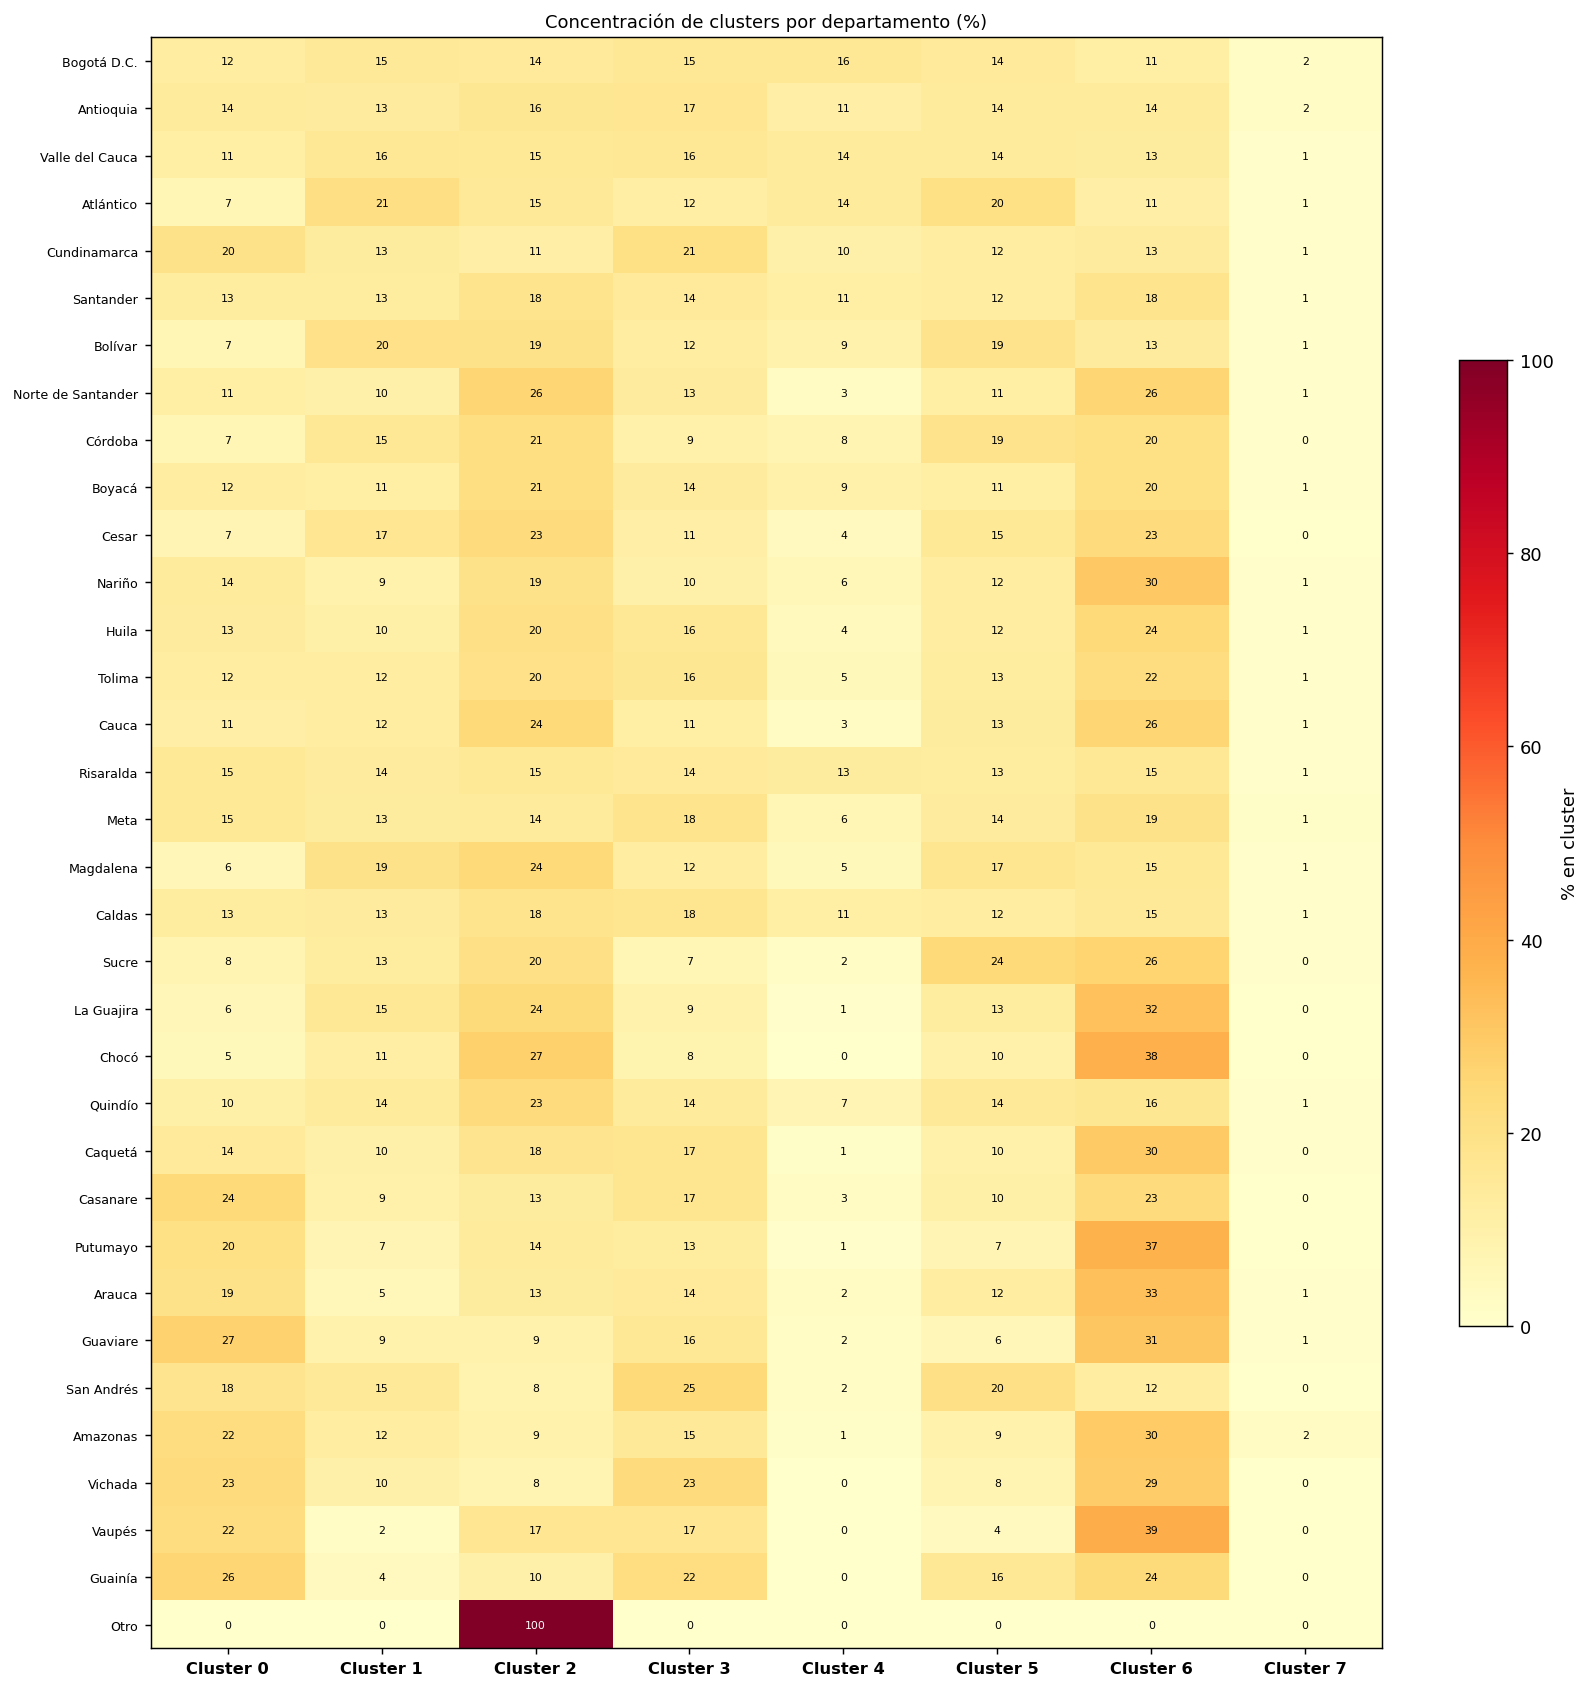


=== Top 5 departamentos por cluster ===

  Cluster 0:
    Guaviare                  27.2%  (n=162)
    Guainía                   25.5%  (n=51)
    Casanare                  23.9%  (n=1,186)
    Vichada                   22.8%  (n=79)
    Vaupés                    22.2%  (n=54)

  Cluster 1:
    Atlántico                 20.9%  (n=11,901)
    Bolívar                   19.6%  (n=6,745)
    Magdalena                 18.8%  (n=3,228)
    Cesar                     16.6%  (n=4,896)
    Valle del Cauca           15.9%  (n=14,062)

  Cluster 2:
    Otro                      100.0%  (n=1)
    Chocó                     27.4%  (n=2,154)
    Norte de Santander        25.5%  (n=5,976)
    Magdalena                 24.5%  (n=3,228)
    Cauca                     24.1%  (n=3,734)

  Cluster 3:
    San Andrés                24.6%  (n=130)
    Vichada                   22.8%  (n=79)
    Guainía                   21.6%  (n=51)
    Cundinamarca              20.6%  (n=10,520)
    Meta                     

In [23]:
DEPTOS = {
    5: 'Antioquia', 8: 'Atlántico', 11: 'Bogotá D.C.', 13: 'Bolívar',
    15: 'Boyacá', 17: 'Caldas', 18: 'Caquetá', 19: 'Cauca',
    20: 'Cesar', 23: 'Córdoba', 25: 'Cundinamarca', 27: 'Chocó',
    41: 'Huila', 44: 'La Guajira', 47: 'Magdalena', 50: 'Meta',
    52: 'Nariño', 54: 'Norte de Santander', 63: 'Quindío',
    66: 'Risaralda', 68: 'Santander', 70: 'Sucre', 73: 'Tolima',
    76: 'Valle del Cauca', 81: 'Arauca', 85: 'Casanare',
    86: 'Putumayo', 88: 'San Andrés', 91: 'Amazonas',
    94: 'Guainía', 95: 'Guaviare', 97: 'Vaupés', 99: 'Vichada'
}

col_geo = 'ESTU_COD_DEPTO_PRESENTACION'
if col_geo not in df_filtrado_full.columns:
    print(f"⚠️  '{col_geo}' no está en df_filtrado_full.")
else:
    df_geo = df_filtrado_full[[col_geo, '_cluster']].copy()
    df_geo['depto'] = df_geo[col_geo].map(DEPTOS).fillna('Otro')

    tabla = pd.crosstab(df_geo['depto'], df_geo['_cluster'],
                        normalize='index').round(3) * 100
    tabla.columns = [NOMBRES_CLUSTERS.get(c, f'C{c}') for c in tabla.columns]
    tabla['n_total'] = df_geo.groupby('depto').size()
    tabla = tabla.sort_values('n_total', ascending=False)

    z_cols = [c for c in tabla.columns if c != 'n_total']
    fig, ax = plt.subplots(figsize=(len(z_cols) * 1.4 + 2,
                                     len(tabla) * 0.35 + 1.2), dpi=130)
    im = ax.imshow(tabla[z_cols].values, aspect='auto',
                   cmap='YlOrRd', vmin=0, vmax=100, interpolation='nearest')
    ax.set_xticks(range(len(z_cols)))
    ax.set_xticklabels(z_cols, fontsize=9, fontweight='bold')
    ax.set_yticks(range(len(tabla)))
    ax.set_yticklabels(tabla.index, fontsize=7)
    ax.set_title("Concentración de clusters por departamento (%)", fontsize=10)
    for row in range(len(tabla)):
        for col in range(len(z_cols)):
            val = tabla[z_cols].values[row, col]
            ax.text(col, row, f'{val:.0f}', ha='center', va='center',
                    fontsize=6, color='white' if val > 60 else 'black')
    plt.colorbar(im, ax=ax, label='% en cluster', shrink=0.6)
    plt.tight_layout()
    plt.savefig('figura_geo_clusters.png', dpi=200, bbox_inches='tight', facecolor='white')
    print("✅ Guardado: figura_geo_clusters.png")
    plt.show()

    print("\n=== Top 5 departamentos por cluster ===")
    for c in z_cols:
        top5 = tabla[c].sort_values(ascending=False).head(5)
        print(f"\n  {c}:")
        for depto, pct in top5.items():
            print(f"    {depto:<25} {pct:.1f}%  (n={tabla.loc[depto,'n_total']:,})")


## 17. Guardar resultados

In [24]:
df_filtrado_full.to_csv(
    '/content/drive/MyDrive/Proyecto/df_clustered_500k.csv', index=False)
print("✅ Dataset con clusters guardado: df_clustered_500k.csv")

pd.DataFrame([m_final]).to_csv(
    '/content/drive/MyDrive/Proyecto/metricas_modelo_final.csv', index=False)
print("✅ Métricas guardadas: metricas_modelo_final.csv")

if 'df_fase1' in dir():
    df_fase1.to_csv(
        '/content/drive/MyDrive/Proyecto/resultados_fase1.csv', index=False)
    print("✅ Resultados Fase 1 guardados: resultados_fase1.csv")


✅ Dataset con clusters guardado: df_clustered_500k.csv
✅ Métricas guardadas: metricas_modelo_final.csv
✅ Resultados Fase 1 guardados: resultados_fase1.csv


In [25]:
# ── Validación representatividad de la muestra ───────────────
print("=" * 65)
print("VALIDACIÓN DE REPRESENTATIVIDAD — Muestra 200k vs Población 452k")
print("=" * 65)

# Variables clave para comparar
vars_validar = {
    'FAMI_ESTRATOVIVIENDA': 'ordinal',
    'ESTU_VALORMATRICULAUNIVERSIDAD': 'ordinal',
    'FAMI_EDUCACIONPADRE': 'ordinal',
    'FAMI_EDUCACIONMADRE': 'ordinal',
    'ESTU_HORASSEMANATRABAJA': 'ordinal',
    'MOD_RAZONA_CUANTITAT_PUNT': 'continua',
    'MOD_LECTURA_CRITICA_PUNT': 'continua',
    'MOD_COMPETEN_CIUDADA_PUNT': 'continua',
    'MOD_INGLES_PUNT': 'continua',
    'MOD_COMUNI_ESCRITA_PUNT': 'continua',
}

from scipy.stats import ks_2samp
import warnings
warnings.filterwarnings("ignore")

resultados_rep = []

print(f"\n{'Variable':<40} {'Media pobl':>10} {'Media mues':>10} {'Dif%':>6} {'KS stat':>8} {'p-valor':>10} {'Repr.'}")
print("-" * 100)

for col, tipo in vars_validar.items():
    if col not in df_limpio.columns or col not in df_filtrado_200k.columns:
        continue

    pob  = pd.to_numeric(df_limpio[col], errors='coerce').dropna()
    mues = pd.to_numeric(df_filtrado_200k[col], errors='coerce').dropna()

    media_pob  = pob.mean()
    media_mues = mues.mean()
    dif_pct    = abs(media_pob - media_mues) / abs(media_pob) * 100 if media_pob != 0 else 0

    # Test KS (Kolmogorov-Smirnov) — compara distribuciones completas
    ks_stat, ks_p = ks_2samp(pob.sample(min(10_000, len(pob)), random_state=42),
                              mues.sample(min(10_000, len(mues)), random_state=42))

    # Criterio: diferencia media < 2% Y KS stat < 0.05
    representa = "✅" if dif_pct < 2 and ks_stat < 0.05 else ("⚠️" if dif_pct < 5 else "❌")

    print(f"{col:<40} {media_pob:>10.3f} {media_mues:>10.3f} {dif_pct:>5.2f}% {ks_stat:>8.4f} {ks_p:>10.4f}  {representa}")
    resultados_rep.append({
        'variable': col, 'media_poblacion': round(media_pob, 3),
        'media_muestra': round(media_mues, 3), 'diferencia_pct': round(dif_pct, 2),
        'ks_stat': round(ks_stat, 4), 'ks_pvalor': round(ks_p, 4),
        'representa': representa
    })

df_rep = pd.DataFrame(resultados_rep)

# Resumen
n_ok  = (df_rep['diferencia_pct'] < 2).sum()
n_warn= ((df_rep['diferencia_pct'] >= 2) & (df_rep['diferencia_pct'] < 5)).sum()
n_mal = (df_rep['diferencia_pct'] >= 5).sum()

print(f"\n{'='*65}")
print(f"  ✅ Diferencia < 2%:  {n_ok}/{len(df_rep)} variables")
print(f"  ⚠️  Diferencia 2-5%: {n_warn}/{len(df_rep)} variables")
print(f"  ❌ Diferencia > 5%:  {n_mal}/{len(df_rep)} variables")
print(f"{'='*65}")

# Guardar
df_rep.to_csv('/content/drive/MyDrive/Proyecto/validacion_representatividad.csv', index=False)
print("✅ Guardado: validacion_representatividad.csv")

VALIDACIÓN DE REPRESENTATIVIDAD — Muestra 200k vs Población 452k

Variable                                 Media pobl Media mues   Dif%  KS stat    p-valor Repr.
----------------------------------------------------------------------------------------------------
FAMI_ESTRATOVIVIENDA                          2.434      2.433  0.04%   0.0094     0.7690  ✅
ESTU_VALORMATRICULAUNIVERSIDAD                3.697      3.696  0.02%   0.0156     0.1753  ✅
FAMI_EDUCACIONPADRE                           3.171      3.178  0.23%   0.0040     1.0000  ✅
FAMI_EDUCACIONMADRE                           3.636      3.634  0.06%   0.0063     0.9888  ✅
ESTU_HORASSEMANATRABAJA                       2.540      2.539  0.04%   0.0057     0.9969  ✅
MOD_RAZONA_CUANTITAT_PUNT                   145.369    145.358  0.01%   0.0114     0.5343  ✅
MOD_LECTURA_CRITICA_PUNT                    148.403    148.369  0.02%   0.0086     0.8534  ✅
MOD_COMPETEN_CIUDADA_PUNT                   143.307    143.335  0.02%   0.0089     0.8